In [7]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

mdir=r'E:CE25007_CRUISE\CE25007_DATA\CE25007_recovery_data'
fles = glob.glob(os.path.join(mdir,'*_data.cnv'))
fles

['E:CE25007_CRUISE\\CE25007_DATA\\CE25007_recovery_data\\16363_data.cnv',
 'E:CE25007_CRUISE\\CE25007_DATA\\CE25007_recovery_data\\16379_data.cnv',
 'E:CE25007_CRUISE\\CE25007_DATA\\CE25007_recovery_data\\21269_data.cnv',
 'E:CE25007_CRUISE\\CE25007_DATA\\CE25007_recovery_data\\23829_data.cnv',
 'E:CE25007_CRUISE\\CE25007_DATA\\CE25007_recovery_data\\23830_data.cnv',
 'E:CE25007_CRUISE\\CE25007_DATA\\CE25007_recovery_data\\7923_data.cnv',
 'E:CE25007_CRUISE\\CE25007_DATA\\CE25007_recovery_data\\9141_data.cnv']

C:\Users\sa01ld\AppData\Local\Temp\ipykernel_1196\2791483952.py:34: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(StringIO(data_str),
C:\Users\sa01ld\AppData\Local\Temp\ipykernel_1196\2791483952.py:34: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(StringIO(data_str),
C:\Users\sa01ld\AppData\Local\Temp\ipykernel_1196\2791483952.py:34: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(StringIO(data_str),
C:\Users\sa01ld\AppData\Local\Temp\ipykernel_1196\2791483952.py:34: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(StringIO(data_str),
C:\U

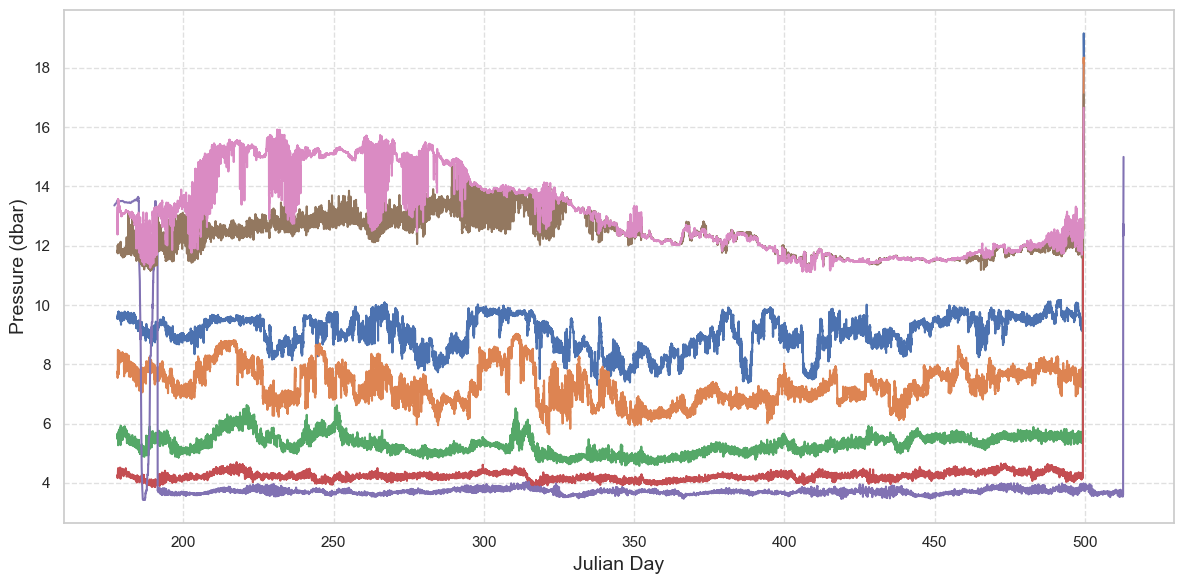

In [9]:
plt.figure(figsize=(12, 6))

for i in fles:
    # Step 1: Read the file and find the line after '*END*'
    with open(i, 'r') as file:
        lines = file.readlines()
    
    # Step 2: Locate the '*END*' line
    start_index = None
    for i, line in enumerate(lines):
        if '*END*' in line:
            start_index = i + 1
            break
    
    if start_index is None:
        raise ValueError("'*END*' not found in the file.")
    
    # Step 3: Grab only the data lines after *END*
    data_lines = lines[start_index:]
    
    # Step 4: Create a StringIO object from data lines
    data_str = ''.join(data_lines)
    
    # Step 5: Define column names manually (based on the metadata in the file)
    column_names = [
        'Temperature (C)', 
        'Conductivity (S/m)', 
        'Pressure (dbar)', 
        'Julian Day', 
        'Flag'
    ]
    
    # Step 6: Load into a DataFrame
    df = pd.read_csv(StringIO(data_str), 
                     delim_whitespace=True, 
                     names=column_names)
    
    # Optional: better aesthetics with seaborn
    sns.set(style="whitegrid")
    
    # Create the plot
    plt.plot(df['Julian Day'], df[ 'Temperature (C)'], linewidth=1.5)
    
    # Labels and title
    plt.xlabel('Julian Day', fontsize=14)
    plt.ylabel('Pressure (dbar)', fontsize=14)
    
    # Optional: grid and layout
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

# Show the plot
plt.show()
